In [2]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import jieba
import numpy as np
from sklearn.impute import SimpleImputer

# 1.特征值含有字符串的时候，如何进行特征提取

In [3]:
def dictvec():
    #sparse=true，输出的是每个不为0的位置的坐标，稀疏矩阵可以节省存储空间
    # DictVectorizer是把字典类型的数据转换成机器学习模型可以使用的特征矩阵
    dict1 = DictVectorizer(sparse=True)

    # fit_transform是先fit再transform,作用是先学习数据，在进行数据的转换
    data = dict1.fit_transform([{'city': '北京', 'temperature': 100},
                               {'city': '上海', 'temperature': 60},
                               {'city': '深圳', 'temperature': 30}])
    print(data)
    print('-'*50)
    print(dict1.get_feature_names_out()) # get_feature_names_out()用于查看特征名称
    print('-'*50)
    print(dict1.inverse_transform(data))  #去看每个特征代表的含义，逆转回去
    return None

dictvec()

  (0, 1)	1.0
  (0, 3)	100.0
  (1, 0)	1.0
  (1, 3)	60.0
  (2, 2)	1.0
  (2, 3)	30.0
--------------------------------------------------
['city=上海' 'city=北京' 'city=深圳' 'temperature']
--------------------------------------------------
[{'city=北京': 1.0, 'temperature': 100.0}, {'city=上海': 1.0, 'temperature': 60.0}, {'city=深圳': 1.0, 'temperature': 30.0}]


# 2.一段英文文本如何变成数值类型

In [11]:
def couvec():
    # 实例化CountVectorizer
    # max_df, min_df整数：指每个词的所有文档词频数不小于最小值，出现该词的文档数目小于等于max_df
    # max_df, min_df小数(0-1之间的）：某个词的出现的次数／所有文档数量
    # 默认会去除单个字母的单词，默认认为这个词对整个样本没有影响,认为其没有语义
    vector = CountVectorizer()

    # 调用fit_transform输入并转换数据
    res = vector.fit_transform(["life is  short,i like python life",
         "life is too long,i dislike python",
         "life is short"])

    # 打印出每个特征值
    print(vector.get_feature_names_out())
    print('-'*50)
    print(res) # 稀疏矩阵，类似于数据结构的稀疏矩阵的三元组方式
    print('-'*50)
    print(type(res))
    # 对照feature_names，标记每个词出现的次数
    print('-'*50)
    print(res.toarray()) #稀疏矩阵转换为数组
    print('-'*50)
    #拿每个样本里的特征进行显示
    print(vector.inverse_transform(res))
    return None
couvec()

['dislike' 'is' 'life' 'like' 'long' 'python' 'short' 'too']
--------------------------------------------------
  (0, 2)	2
  (0, 1)	1
  (0, 6)	1
  (0, 3)	1
  (0, 5)	1
  (1, 2)	1
  (1, 1)	1
  (1, 5)	1
  (1, 7)	1
  (1, 4)	1
  (1, 0)	1
  (2, 2)	1
  (2, 1)	1
  (2, 6)	1
--------------------------------------------------
<class 'scipy.sparse._csr.csr_matrix'>
--------------------------------------------------
[[0 1 2 1 0 1 1 0]
 [1 1 1 0 1 1 0 1]
 [0 1 1 0 0 0 1 0]]
--------------------------------------------------
[array(['life', 'is', 'short', 'like', 'python'], dtype='<U7'), array(['life', 'is', 'python', 'too', 'long', 'dislike'], dtype='<U7'), array(['life', 'is', 'short'], dtype='<U7')]


# 一段汉字如何数值化，对于汉字不能用空格来分割

In [12]:
def countvec():
    """
    对文本进行特征值化,单个汉字单个字母不统计，因为单个汉字字母没有意义
    :return: None
    """
    cv = CountVectorizer()

    data = cv.fit_transform(["人生苦短，我 喜欢 python python", "人生漫长，不用 python"])

    print(cv.get_feature_names_out())
    print('-'*50)
    print(data) #稀疏存储，只记录非零位置
    print('-'*50)
    print(data.toarray())

    return None


countvec()

['python' '不用' '人生漫长' '人生苦短' '喜欢']
--------------------------------------------------
  (0, 3)	1
  (0, 4)	1
  (0, 0)	2
  (1, 0)	1
  (1, 2)	1
  (1, 1)	1
--------------------------------------------------
[[2 0 0 1 1]
 [1 1 1 0 0]]


# 1.3掌握如何对中文进行分词

In [21]:
def cutword():
    """
    通过jieba对中文进行分词
    """
    con1 = jieba.cut("今天很残酷，明天更残酷，后天很美好，但绝对大部分是死在明天晚上，所以每个人不要放弃今天。")

    con2 = jieba.cut("我们看到的从很远星系来的光是在几百万年之前发出的，这样当我们看到宇宙时，我们是在看它的过去。")

    con3 = jieba.cut("如果只用一种方式了解某样事物，你就不会真正了解它。了解事物真正含义的秘密取决于如何将其与我们所了解的事物相联系。")

    #转换成列表
    print(type(con1))  # 此时的con1的类型是生成器
    print('-' * 50)
    # 把生成器转换成列表
    content1 =list(con1)
    content2 =list(con2)
    content3 =list(con3)
    # 把列表转换成字符串，每个词之间用空格隔开
    print('-' * 50)
    c1 = ' '.join(content1)
    c2 = ' '.join(content2)
    c3 = ' '.join(content3)
    return c1,c2,c3

def Chinesevec():
    c1,c2,c3 = cutword()
    print('-'*50)
    print(c1)
    print(c2)
    print(c3)
    print('-'*50)
    cv = CountVectorizer()
    data = cv.fit_transform([c1,c2,c3])
    print(cv.get_feature_names_out()) # 返回每个特征值
    print(data)
    print('-'*50)
    print(data.toarray()) # 将稀疏矩阵转换成列表类型
    return None
Chinesevec()


<class 'generator'>
--------------------------------------------------
--------------------------------------------------
--------------------------------------------------
今天 很 残酷 ， 明天 更 残酷 ， 后天 很 美好 ， 但 绝对 大部分 是 死 在 明天 晚上 ， 所以 每个 人 不要 放弃 今天 。
我们 看到 的 从 很 远 星系 来 的 光是在 几百万年 之前 发出 的 ， 这样 当 我们 看到 宇宙 时 ， 我们 是 在 看 它 的 过去 。
如果 只用 一种 方式 了解 某样 事物 ， 你 就 不会 真正 了解 它 。 了解 事物 真正 含义 的 秘密 取决于 如何 将 其 与 我们 所 了解 的 事物 相 联系 。
--------------------------------------------------
['一种' '不会' '不要' '之前' '了解' '事物' '今天' '光是在' '几百万年' '发出' '取决于' '只用' '后天' '含义'
 '大部分' '如何' '如果' '宇宙' '我们' '所以' '放弃' '方式' '明天' '星系' '晚上' '某样' '残酷' '每个'
 '看到' '真正' '秘密' '绝对' '美好' '联系' '过去' '这样']
  (0, 6)	2
  (0, 26)	2
  (0, 22)	2
  (0, 12)	1
  (0, 32)	1
  (0, 31)	1
  (0, 14)	1
  (0, 24)	1
  (0, 19)	1
  (0, 27)	1
  (0, 2)	1
  (0, 20)	1
  (1, 18)	3
  (1, 28)	2
  (1, 23)	1
  (1, 7)	1
  (1, 8)	1
  (1, 3)	1
  (1, 9)	1
  (1, 35)	1
  (1, 17)	1
  (1, 34)	1
  (2, 18)	1
  (2, 16)	1
  (2, 11)	1
  (2, 0)	1
  (2, 21)	1
  (2, 4)	4
  (2, 25)	1
  (2, 5)	

# 1.4 tf-idf

In [24]:
# 规范{'l1'，'l2'}，默认='l2'
# 每个输出行都有单位范数，或者：
#
# 'l2'：向量元素的平方和为 1。当应用 l2 范数时，两个向量之间的余弦相似度是它们的点积。
#
# 'l1'：向量元素的绝对值之和为 1。参见preprocessing.normalize。

# smooth_idf布尔值，默认 = True
# 通过在文档频率上加一来平滑 idf 权重，就好像看到一个额外的文档包含集合中的每个术语恰好一次。防止零分裂。


# 比如训练集中有某个词，测试集中没有，就是生僻词，就会造成n(x)分母为零，log(n/n(x)),从而出现零分裂

def tfidfvec():
    """
    中文特征值化，计算tfidf值
    :return:
    """
    c1,c2,c3 = cutword()
    tf =TfidfVectorizer(smooth_idf=True) # 是为了防止训练集当中有而测试集当中没有的情况，会将测试集和训练集的次数全都加上1
    data =tf.fit_transform([c1,c2,c3])
    print(tf.get_feature_names_out()) # 查看所有的特征值
    print('-'*50)
    print(type(data))
    print('-'*50)
    print(data.toarray())
    return None
tfidfvec()

<class 'generator'>
--------------------------------------------------
--------------------------------------------------
['一种' '不会' '不要' '之前' '了解' '事物' '今天' '光是在' '几百万年' '发出' '取决于' '只用' '后天' '含义'
 '大部分' '如何' '如果' '宇宙' '我们' '所以' '放弃' '方式' '明天' '星系' '晚上' '某样' '残酷' '每个'
 '看到' '真正' '秘密' '绝对' '美好' '联系' '过去' '这样']
--------------------------------------------------
<class 'scipy.sparse._csr.csr_matrix'>
--------------------------------------------------
[[0.         0.         0.21821789 0.         0.         0.
  0.43643578 0.         0.         0.         0.         0.
  0.21821789 0.         0.21821789 0.         0.         0.
  0.         0.21821789 0.21821789 0.         0.43643578 0.
  0.21821789 0.         0.43643578 0.21821789 0.         0.
  0.         0.21821789 0.21821789 0.         0.         0.        ]
 [0.         0.         0.         0.2410822  0.         0.
  0.         0.2410822  0.2410822  0.2410822  0.         0.
  0.         0.         0.         0.         0.         0.

# 2.特征处理，不同的特征值拉到同一个量纲中

In [25]:
def mm():
    """
    归一化处理，容易受到极值的影响,feature_range一般设置为(0,1)或者(-1,1)
    :return:
    """
    mm = MinMaxScaler(feature_range=(0,1))  # mm只是一个生成器
    data = mm.fit_transform([[90, 2, 10, 40], [60, 4, 15, 45], [75, 3, 13, 46]])  # 训练集
    print(data)
    print('-'*50)
    out = mm.transform([[1, 2, 3, 4],[6, 5, 8, 7]])  # 测试集
    print(out)
    return None
#transform和fit_transform不同是，transform用于测试集，而且不会重新找最小值和最大值
mm()

[[1.         0.         0.         0.        ]
 [0.         1.         1.         0.83333333]
 [0.5        0.5        0.6        1.        ]]
--------------------------------------------------
[[-1.96666667  0.         -1.4        -6.        ]
 [-1.8         1.5        -0.4        -5.5       ]]


In [32]:
def stand():
    """
    标准化缩放，不是标准正太分布，只均值为0，方差为1的分布
    :return:
    """
    std = StandardScaler()
    data = std.fit_transform([[1., -1., 3.], [2., 4., 2.], [4., 6., -1.]])

    print(data)
    print('-' * 50)
    print(std.mean_) #  用于计算每一列特征值的平均值
    print('-' * 50)
    print(std.var_) # 计算每个特征列的方差
    print(std.n_samples_seen_)  # 样本数
    return data
data = stand()

[[-1.06904497 -1.35873244  0.98058068]
 [-0.26726124  0.33968311  0.39223227]
 [ 1.33630621  1.01904933 -1.37281295]]
--------------------------------------------------
[2.33333333 3.         1.33333333]
--------------------------------------------------
[1.55555556 8.66666667 2.88888889]
3


In [34]:
print(data)

[[-1.06904497 -1.35873244  0.98058068]
 [-0.26726124  0.33968311  0.39223227]
 [ 1.33630621  1.01904933 -1.37281295]]


In [35]:
std1 = StandardScaler()
#为了证明上面输出的结果的均值是为0的，方差为1
data1 = std1.fit_transform(data)
# print(data1)  #这个并不是我们想看的，没意义
# 均值
print(std1.mean_)
# 方差
print(std1.var_)

[-1.48029737e-16  7.40148683e-17  7.40148683e-17]
[1. 1. 1.]


# transform和fit_transform不同是，transform用于测试集，而且不会重新找最小值和最大值,不会重新计算均值方差

# 3.缺失值处理

In [36]:
def im():
    # 缺失值处理的类型必须是nan,NaN这种类型，如果是？，就需要用replace去代替
    im = SimpleImputer(missing_values=np.nan,strategy='mean')  # SimpleImputer是用来处理缺失值的一个工具
    data = im.fit_transform([[1, 2], [np.nan, 3], [7, 6], [3, 2]])
    print(data)
    return None
im()

[[1.         2.        ]
 [3.66666667 3.        ]
 [7.         6.        ]
 [3.         2.        ]]


# 4.降维
# 降维就是减少特征数量，从而提高模型的训练速度

In [38]:
def var():

    #默认只删除方差为0,threshold是方差阈值，删除比这个值小的那些特征
    var = VarianceThreshold(threshold=0.1)
    data = var.fit_transform([[0, 2, 0, 3],
                              [0, 1, 4, 3],
                              [0, 1, 1, 3]])
    print(data)
    # 获取剩余特征值的列编号,get_support函数给出了剩余特征值在哪几列
    print('The Support is  %s'%var.get_support(True))
    return None
var()

[[2 0]
 [1 4]
 [1 1]]
The Support is  [1 2]


In [40]:
def pca():
    # n_ components:小数 0~1 90% 业界选择 90~95%

    # 当n_components的值为0到1之间的浮点数时，表示我们希望保留的主成分解释的方差比例。方差比例是指 得到输出的每一列的方差值和除以原有数据方差之和。
    # 具体而言，n_components=0.9表示我们希望选择足够的主成分，以使它们解释数据方差的90%。

    # n_components如果是整数   减少到的特征数量
    # 原始数据方差
    original_value = np.array([[2, 8, 4, 5], [6, 3, 0, 8], [5, 4, 9, 1]])
    print(np.var(original_value,axis = 0).sum()) # 最初数据的方差
    print('-' * 50)
    pca =PCA(n_components=0.9)
    data =pca.fit_transform(original_value)
    print(pca)
    print(type(pca))
    # 计算data的方差
    print(np.var(data,axis = 0).sum())
    print('-'*50)
    print(pca.explained_variance_ratio_) # 每个主成分解释信息的比例
    # 计算data方差占总方差的比例
    print(pca.explained_variance_ratio_.sum())
    return None
pca()

29.333333333333336
--------------------------------------------------
PCA(n_components=0.9)
<class 'sklearn.decomposition._pca.PCA'>
29.333333333333332
--------------------------------------------------
[0.75 0.25]
1.0


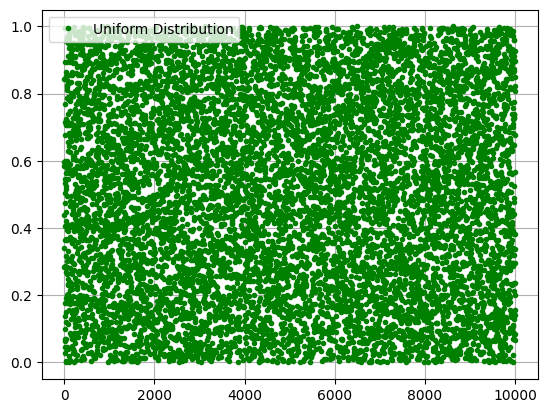

In [41]:
from matplotlib import pyplot as plt
x = np.random.rand(10000) #每个的概率
t = np.arange(len(x))
plt.plot(t,x,'g.',label="Uniform Distribution")
plt.legend(loc="upper left")
plt.grid()
plt.show()